# Analysis — `suite-*`

Generated by `hmb analysis init`. It reads the raw trial artefacts under
`jobs/suite-*/` through `harbor_methodology_bench.analysis`, which derives what the
cell-level report cannot carry: per-test partial credit, budget utilisation, timeout
censoring, per-step telemetry, and a strict adherence measure.

Run it with the analysis dependency group:

```bash
uv sync --group analysis
uv run --group analysis jupyter lab results/analysis-suite/suite_analysis.ipynb
```

Every figure is written to `figures/` as a 300 dpi PNG and an SVG, sized for a 16:9 slide.

**Read the design questions before the numbers.** A benchmark comparison is only as good
as its ability to discriminate: a task that every condition passes carries no information
about the comparison, however expensive it was. Section 2 quantifies that for this run.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from scipy import stats

from harbor_methodology_bench.analysis import extract_all, write_csvs

PATTERN = "suite-*"

ANALYSIS_DIR = Path.cwd()
REPO_ROOT = next(p for p in [ANALYSIS_DIR, *ANALYSIS_DIR.parents] if (p / "pyproject.toml").is_file())
JOBS_DIR = REPO_ROOT / "jobs"
CATALOGUE = REPO_ROOT / "results" / "task_catalogue.json"   # optional; hmb catalogue --json-out
DATA_DIR = ANALYSIS_DIR / "data"
FIG_DIR = ANALYSIS_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

CATALOGUE_MISSING = not CATALOGUE.is_file()
if CATALOGUE_MISSING:
    print(
        f"warn  no catalogue at {CATALOGUE.relative_to(REPO_ROOT)}; "
        "difficulty, category, axes, expert_min, budget_sec and budget_used "
        "will be empty.\n"
        "      write it with:  hmb catalogue --config <config> --suite all "
        "--json-out results/task_catalogue.json"
    )

tables = extract_all(JOBS_DIR, PATTERN, CATALOGUE, root=REPO_ROOT)
write_csvs(DATA_DIR, tables)

trials = pd.DataFrame(tables["trials"])
tests = pd.DataFrame(tables["tests"])
steps = pd.DataFrame(tables["steps"])
calls = pd.DataFrame(tables["tool_calls"])

# Baseline first, then the other conditions alphabetically, so colour and column
# order mean the same thing in every figure.
CONDITIONS = (["baseline"] if "baseline" in set(trials.condition) else []) + sorted(
    set(trials.condition) - {"baseline"}
)
trials["condition"] = pd.Categorical(trials.condition, CONDITIONS, ordered=True)

print(f"{len(trials)} trials · {trials.task.nunique()} tasks · {len(CONDITIONS)} conditions: {', '.join(CONDITIONS)}")
print(f"spend ${trials.cost_usd.sum():,.2f} · agent wall-clock {trials.agent_sec.sum()/3600:.1f} h")
trials.head()

96 trials · 16 tasks · 3 conditions: baseline, codezen-viable, sdd
spend $114.90 · agent wall-clock 18.3 h


,job_name,trial_name,task,condition,agent,model,reward,success,exception_type,agent_timeout,...,difficulty,category,axes,expert_min,budget_sec,instruction_words,requirement_lines,test_code_bytes,requires_own_tests,budget_used
0,suite-claude-code,adaptive-rejection-sampler__KWhHbgi,adaptive-rejection-sampler,codezen-viable,claude-code,claude-sonnet-5,1.0,True,AgentTimeoutError,True,...,medium,scientific-computing,spec-dense;verification-heavy,180.0,900.0,411,15,9898,True,1.000001
1,suite-claude-code,adaptive-rejection-sampler__RwtBg3X,adaptive-rejection-sampler,baseline,claude-code,claude-sonnet-5,0.0,False,NaN,False,...,medium,scientific-computing,spec-dense;verification-heavy,180.0,900.0,411,15,9898,True,0.498091
2,suite-claude-code,adaptive-rejection-sampler__VpmwL24,adaptive-rejection-sampler,baseline,claude-code,claude-sonnet-5,0.0,False,NaN,False,...,medium,scientific-computing,spec-dense;verification-heavy,180.0,900.0,411,15,9898,True,0.302000
3,suite-claude-code,adaptive-rejection-sampler__YFqyAn5,adaptive-rejection-sampler,sdd,claude-code,claude-sonnet-5,0.0,False,NaN,False,...,medium,scientific-computing,spec-dense;verification-heavy,180.0,900.0,411,15,9898,True,0.911551
4,suite-claude-code,adaptive-rejection-sampler__gMYvacz,adaptive-rejection-sampler,sdd,claude-code,claude-sonnet-5,1.0,True,NaN,False,...,medium,scientific-computing,spec-dense;verification-heavy,180.0,900.0,411,15,9898,True,0.912213


## 0. Chart style

Categorical slots from a validated palette, assigned to conditions in a fixed order and
never re-assigned, so a colour means one condition throughout. Pass/fail uses the reserved
status colours and always carries a glyph as well, never colour alone.

In [2]:
SURFACE, INK, INK_2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
# Categorical slots 1-8, in the order that passes the colour-blindness gates.
SLOTS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
COLOR = {cond: SLOTS[i % len(SLOTS)] for i, cond in enumerate(CONDITIONS)}
GOOD, WARNING, CRITICAL = "#0ca30c", "#fab219", "#d03b3b"
BLUE_RAMP = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab"]

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.family": ["DejaVu Sans"], "font.size": 12,
    "axes.titlesize": 15, "axes.titleweight": "bold", "axes.titlecolor": INK, "axes.titlepad": 12,
    "axes.labelsize": 12, "axes.labelcolor": INK_2, "axes.edgecolor": AXIS, "axes.linewidth": 0.8,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelcolor": INK_2, "ytick.labelcolor": INK_2,
    "xtick.labelsize": 11, "ytick.labelsize": 11,
    "legend.frameon": False, "legend.fontsize": 11, "legend.labelcolor": INK_2,
    "grid.color": GRID, "grid.linewidth": 0.8, "grid.linestyle": "-",
    "figure.dpi": 120,
    # A dollar sign in a label must render as a dollar sign, not open mathtext.
    "text.parse_math": False,
})


def bare(ax, grid_axis="y"):
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.spines["left"].set_color(AXIS)
    ax.spines["bottom"].set_color(AXIS)
    if grid_axis:
        ax.grid(True, axis=grid_axis, zorder=0)
        ax.set_axisbelow(True)
    return ax


def titled(ax, title, sub=None):
    ax.set_title(title, loc="left", pad=30 if sub else 12)
    if sub:
        ax.text(0, 1.012, sub, transform=ax.transAxes, fontsize=10.5, color=MUTED, va="bottom")


def save(fig, name, note=None):
    if note:
        fig.text(0.01, 0.005, note, ha="left", va="bottom", fontsize=9, color=MUTED)
    fig.savefig(FIG_DIR / f"{name}.png", dpi=300, bbox_inches="tight")
    fig.savefig(FIG_DIR / f"{name}.svg", bbox_inches="tight")
    print(f"figures/{name}.png  figures/{name}.svg")


def wilson(k, n, z=1.96):
    if n == 0:
        return (np.nan, np.nan)
    p, denom = k / n, 1 + z**2 / n
    centre = (p + z**2 / (2 * n)) / denom
    half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom
    return (max(0.0, centre - half), min(1.0, centre + half))

## 1. Outcome

Three views of the same trials: the binary reward, the fraction of the verifier's
individual tests that passed (free, and ~4× the graded outcomes), and those test outcomes
pooled.

In [3]:
summary = (
    trials.groupby("condition", observed=True)
    .agg(trials=("task", "size"), successes=("success", "sum"), success_rate=("success", "mean"),
         partial_credit=("partial_credit", "mean"), cost_usd=("cost_usd", "sum"),
         cost_per_trial=("cost_usd", "mean"), agent_sec=("agent_sec", "mean"),
         budget_used=("budget_used", "mean"), output_tokens=("output_tokens", "mean"),
         steps=("n_steps", "mean"), tool_calls=("n_tool_calls", "mean"),
         agent_timeouts=("agent_timeout", "sum"), skill_calls=("n_toolkit_skill_calls", "sum"))
    .assign(cost_per_success=lambda d: d.cost_usd / d.successes.replace(0, np.nan))
)
summary.round(3)

,trials,successes,success_rate,partial_credit,cost_usd,cost_per_trial,agent_sec,budget_used,output_tokens,steps,tool_calls,agent_timeouts,skill_calls,cost_per_success
condition,,,,,,,,,,,,,,
baseline,32,8,0.250,0.533,21.874,0.684,597.926,0.302,26921.219,21.875,23.406,4,0,2.734
codezen-viable,32,11,0.344,0.516,68.134,2.129,865.703,0.468,80644.844,48.031,51.344,7,28,6.194
sdd,32,7,0.219,0.448,24.895,0.778,592.515,0.331,29179.844,24.781,24.969,3,27,3.556


figures/01-outcome.png  figures/01-outcome.svg


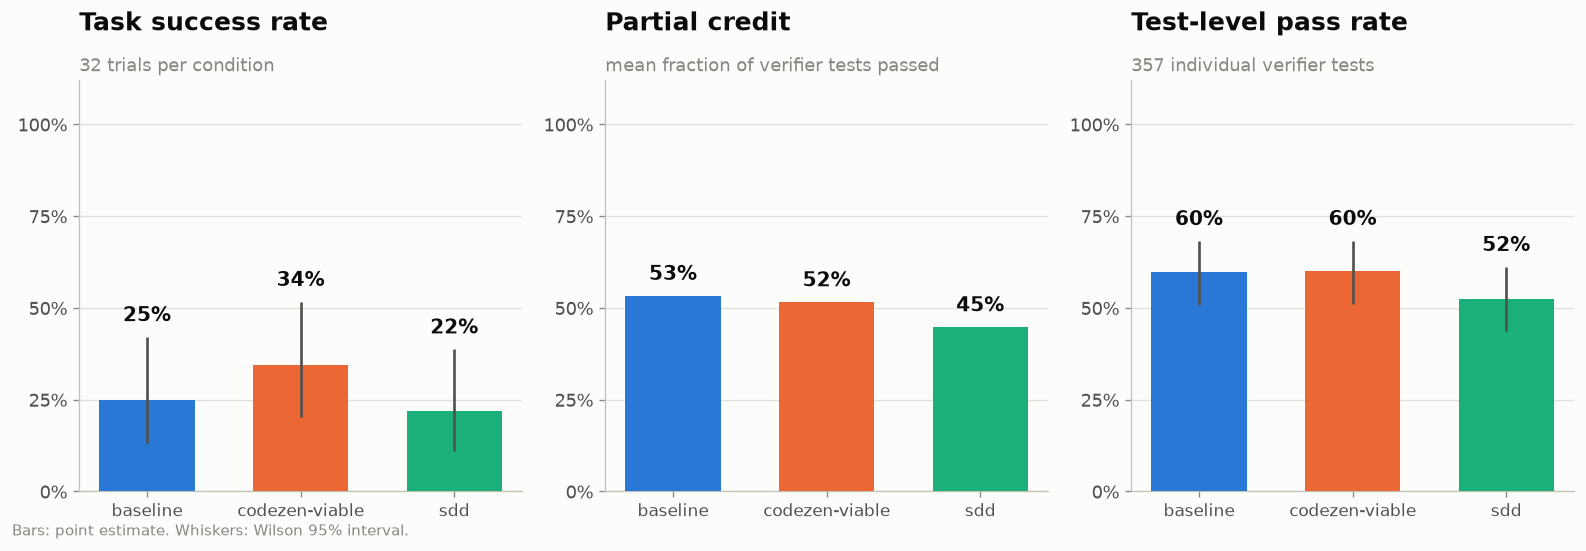

In [4]:
test_pass = (
    tests.assign(passed=lambda d: (d.status == "passed").astype(int))
    .groupby("condition").agg(n_tests=("passed", "size"), pass_rate=("passed", "mean"))
    .reindex(CONDITIONS)
) if len(tests) else pd.DataFrame(index=CONDITIONS, columns=["n_tests", "pass_rate"]).fillna(np.nan)

panels = [
    ("Task success rate", [summary.loc[c, "success_rate"] for c in CONDITIONS],
     [wilson(summary.loc[c, "successes"], summary.loc[c, "trials"]) for c in CONDITIONS],
     f"{int(summary.trials.max())} trials per condition"),
    ("Partial credit", [trials.loc[trials.condition == c, "partial_credit"].mean() for c in CONDITIONS],
     None, "mean fraction of verifier tests passed"),
    ("Test-level pass rate", [test_pass.loc[c, "pass_rate"] for c in CONDITIONS],
     [wilson((test_pass.loc[c, "pass_rate"] or 0) * (test_pass.loc[c, "n_tests"] or 0),
             test_pass.loc[c, "n_tests"] or 0) for c in CONDITIONS],
     f"{int(test_pass.n_tests.sum() or 0)} individual verifier tests"),
]

fig, axes = plt.subplots(1, 3, figsize=(13.33, 4.6))
for ax, (title, values, cis, sub) in zip(axes, panels):
    x = np.arange(len(CONDITIONS))
    for i, cond in enumerate(CONDITIONS):
        value = 0 if pd.isna(values[i]) else values[i]
        ax.bar(x[i], value, width=0.62, color=COLOR[cond], zorder=3)
        top = max(value, cis[i][1] if cis and not pd.isna(cis[i][1]) else 0)
        ax.text(x[i], top + 0.03, f"{value*100:.0f}%", ha="center", va="bottom",
                fontsize=12, color=INK, fontweight="bold")
    if cis:
        for i, (lo, hi) in enumerate(cis):
            if not pd.isna(lo):
                ax.plot([x[i], x[i]], [lo, hi], color=INK_2, lw=1.6, zorder=4, solid_capstyle="butt")
    bare(ax)
    ax.set_xticks(x, CONDITIONS, fontsize=10)
    ax.set_ylim(0, 1.12)
    ax.set_yticks(np.arange(0, 1.01, 0.25), [f"{v:.0%}" for v in np.arange(0, 1.01, 0.25)])
    titled(ax, title, sub)
fig.tight_layout()
save(fig, "01-outcome", "Bars: point estimate. Whiskers: Wilson 95% interval.")
plt.show()

### Paired tests

Every task runs in every condition, so the comparison is paired: exact McNemar on the
binary outcome, Wilcoxon signed-rank on the continuous quantities. Only *discordant* pairs
carry information about a binary comparison.

In [5]:
outcome = trials.pivot_table(index="task", columns="condition", values="success", observed=True)[CONDITIONS]

rows = []
for other in CONDITIONS[1:]:
    base = CONDITIONS[0]
    only_base = int(((outcome[base] == 1) & (outcome[other] == 0)).sum())
    only_other = int(((outcome[base] == 0) & (outcome[other] == 1)).sum())
    n_disc = only_base + only_other
    p = stats.binomtest(only_other, n_disc, 0.5).pvalue if n_disc else 1.0
    rows.append({"comparison": f"{base} vs {other}", f"only {base}": only_base,
                 f"only other": only_other, "discordant (effective n)": n_disc,
                 "concordant (uninformative)": len(outcome) - n_disc, "exact McNemar p": round(p, 3)})
pd.DataFrame(rows)

,comparison,only baseline,only other,discordant (effective n),concordant (uninformative),exact McNemar p
0,baseline vs codezen-viable,0,1,1,15,1.0
1,baseline vs sdd,1,0,1,15,1.0


In [6]:
metric_rows = []
for metric in ["partial_credit", "cost_usd", "agent_sec", "output_tokens", "n_steps",
               "n_tool_calls", "budget_used"]:
    if metric not in trials.columns or not pd.api.types.is_numeric_dtype(trials[metric]):
        print(f"skip  {metric}: absent or non-numeric (a missing catalogue empties budget_used)")
        continue
    pv = trials.pivot_table(index="task", columns="condition", values=metric, observed=True)
    if not {CONDITIONS[0], *CONDITIONS[1:]} & set(pv.columns):
        print(f"skip  {metric}: no condition survived the pivot (every value is NaN)")
        continue
    for other in CONDITIONS[1:]:
        if CONDITIONS[0] not in pv.columns or other not in pv.columns:
            continue
        sub = pv[[CONDITIONS[0], other]].dropna()
        if len(sub) < 3:
            continue
        delta = sub[other] - sub[CONDITIONS[0]]
        metric_rows.append({
            "metric": metric, "vs": other, "n_pairs": len(sub),
            "median delta": delta.median(), "mean delta": delta.mean(),
            "ratio of totals": sub[other].sum() / sub[CONDITIONS[0]].sum(),
            "wilcoxon p": stats.wilcoxon(sub[other], sub[CONDITIONS[0]]).pvalue,
        })
paired = pd.DataFrame(metric_rows)
paired.round(3)

,metric,vs,n_pairs,median delta,mean delta,ratio of totals,wilcoxon p
0,partial_credit,codezen-viable,16,0.000,-0.022,0.960,1.000
1,partial_credit,sdd,16,0.000,-0.090,0.833,0.440
2,cost_usd,codezen-viable,16,0.341,1.446,3.115,0.009
3,cost_usd,sdd,16,0.005,0.094,1.138,0.821
4,agent_sec,codezen-viable,16,197.554,267.777,1.448,0.117
5,agent_sec,sdd,16,-12.890,-5.411,0.991,0.669
6,output_tokens,codezen-viable,16,16340.750,53723.625,2.996,0.016
7,output_tokens,sdd,16,369.500,2258.625,1.084,0.669
8,n_steps,codezen-viable,16,5.500,26.156,2.196,0.013
9,n_steps,sdd,16,0.250,2.906,1.133,0.819


## 2. Could this design measure anything?

A task every condition passes — or every condition fails — drops out of a paired
comparison. The effective sample size is the discordant-pair count above, not the task
count.

figures/02-outcome-matrix.png  figures/02-outcome-matrix.svg


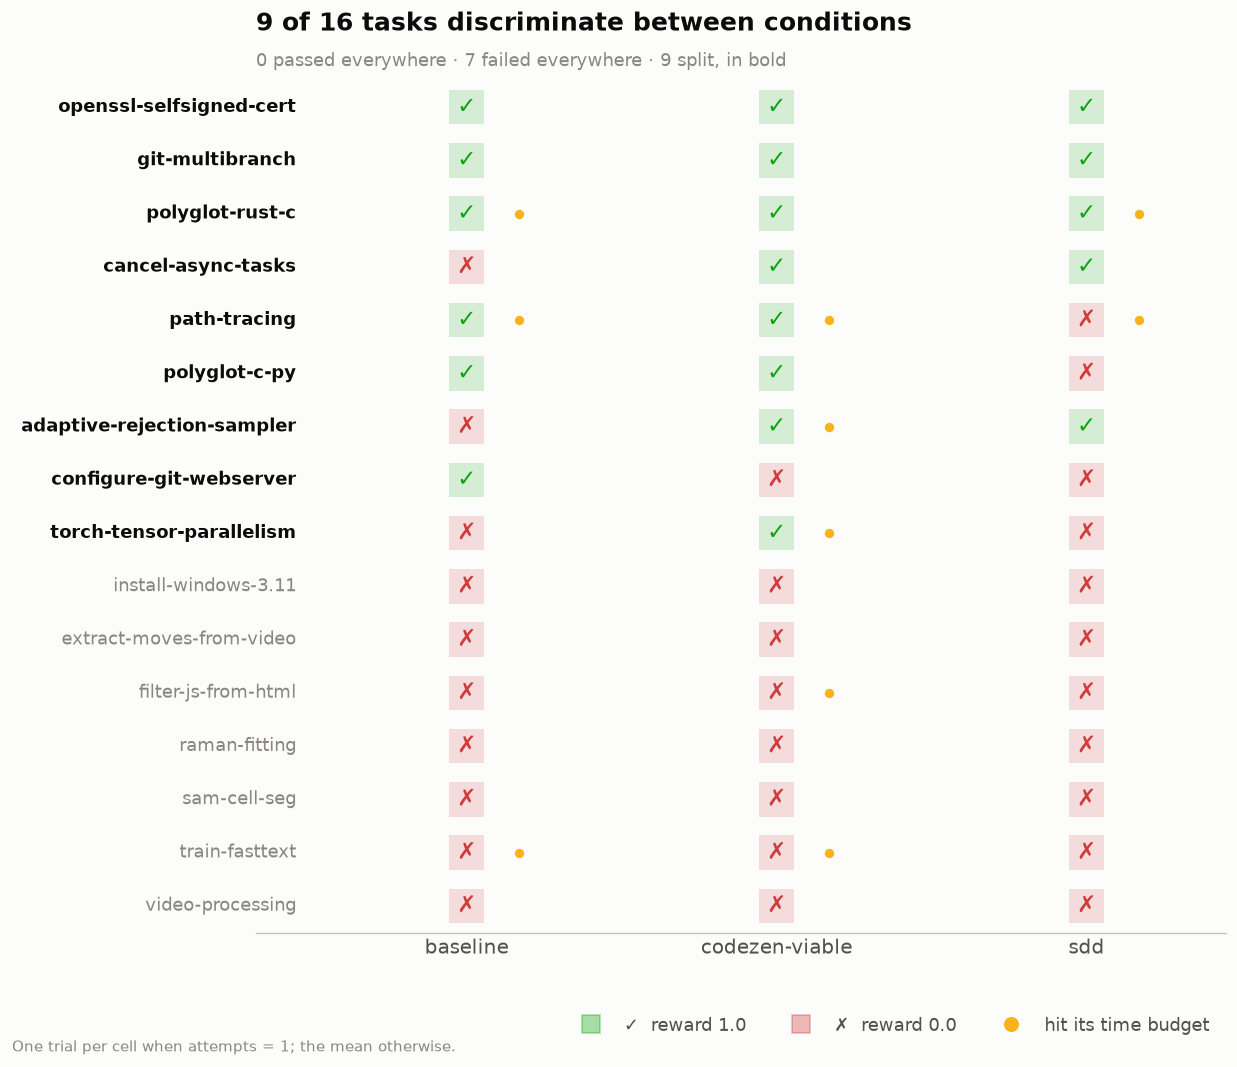

spend on tasks that carried no information: $68.04 of $114.90 (59%)


In [7]:
timeouts = trials.pivot_table(index="task", columns="condition", values="agent_timeout",
                              observed=True, aggfunc="max")[CONDITIONS]
order = outcome.sum(axis=1).sort_values(ascending=False).index
outcome_sorted, timeouts = outcome.loc[order], timeouts.loc[order]

n_cond = len(CONDITIONS)
n_all_pass = int((outcome_sorted.sum(axis=1) == n_cond).sum())
n_all_fail = int((outcome_sorted.sum(axis=1) == 0).sum())
n_split = len(outcome_sorted) - n_all_pass - n_all_fail
split = set(outcome_sorted.index[(outcome_sorted.sum(axis=1) > 0) & (outcome_sorted.sum(axis=1) < n_cond)])

fig, ax = plt.subplots(figsize=(2.6 + 2.6 * n_cond, 0.42 * len(outcome_sorted) + 2.2))
for j, cond in enumerate(CONDITIONS):
    for i, task in enumerate(outcome_sorted.index):
        passed = bool(outcome_sorted.loc[task, cond])
        color = GOOD if passed else CRITICAL
        ax.scatter(j, i, s=430, marker="s", color=color, alpha=0.16, zorder=2, edgecolors="none")
        ax.text(j, i, "✓" if passed else "✗", ha="center", va="center", fontsize=14,
                color=color, fontweight="bold", zorder=3)
        if bool(timeouts.loc[task, cond]):
            ax.scatter(j + 0.17, i, s=52, marker="o", color=WARNING, zorder=3,
                       edgecolors=SURFACE, linewidths=1.6)
for i, task in enumerate(outcome_sorted.index):
    ax.text(-0.55, i, task, ha="right", va="center", fontsize=11,
            color=INK if task in split else MUTED,
            fontweight="bold" if task in split else "normal")
ax.set_xlim(-0.68, n_cond - 0.55)
ax.set_ylim(len(outcome_sorted) - 0.5, -0.5)
ax.set_xticks(range(n_cond), CONDITIONS)
ax.set_yticks([])
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
ax.spines["bottom"].set_color(AXIS)
ax.tick_params(axis="x", length=0, labelsize=12)
titled(ax, f"{n_split} of {len(outcome_sorted)} tasks discriminate between conditions",
       f"{n_all_pass} passed everywhere · {n_all_fail} failed everywhere · {n_split} split, in bold")
ax.legend(handles=[
    Line2D([], [], marker="s", color=GOOD, lw=0, markersize=11, alpha=0.35, label="✓  reward 1.0"),
    Line2D([], [], marker="s", color=CRITICAL, lw=0, markersize=11, alpha=0.35, label="✗  reward 0.0"),
    Line2D([], [], marker="o", color=WARNING, lw=0, markersize=8, label="hit its time budget"),
], loc="lower right", bbox_to_anchor=(1.0, -0.14), ncol=3)
fig.tight_layout()
save(fig, "02-outcome-matrix", "One trial per cell when attempts = 1; the mean otherwise.")
plt.show()

concordant_cost = trials[trials.task.isin(set(outcome_sorted.index) - split)].cost_usd.sum()
print(f"spend on tasks that carried no information: ${concordant_cost:,.2f} of ${trials.cost_usd.sum():,.2f}"
      f" ({concordant_cost/trials.cost_usd.sum():.0%})")

## 3. Cost, time and budget

Cost is continuous per trial, so it separates conditions at sample sizes where a rare
binary outcome cannot. Budget utilisation is the share of each task's *declared* agent
budget consumed — the task-normalised form of duration, and the mechanism behind
censoring.

figures/03-overhead.png  figures/03-overhead.svg


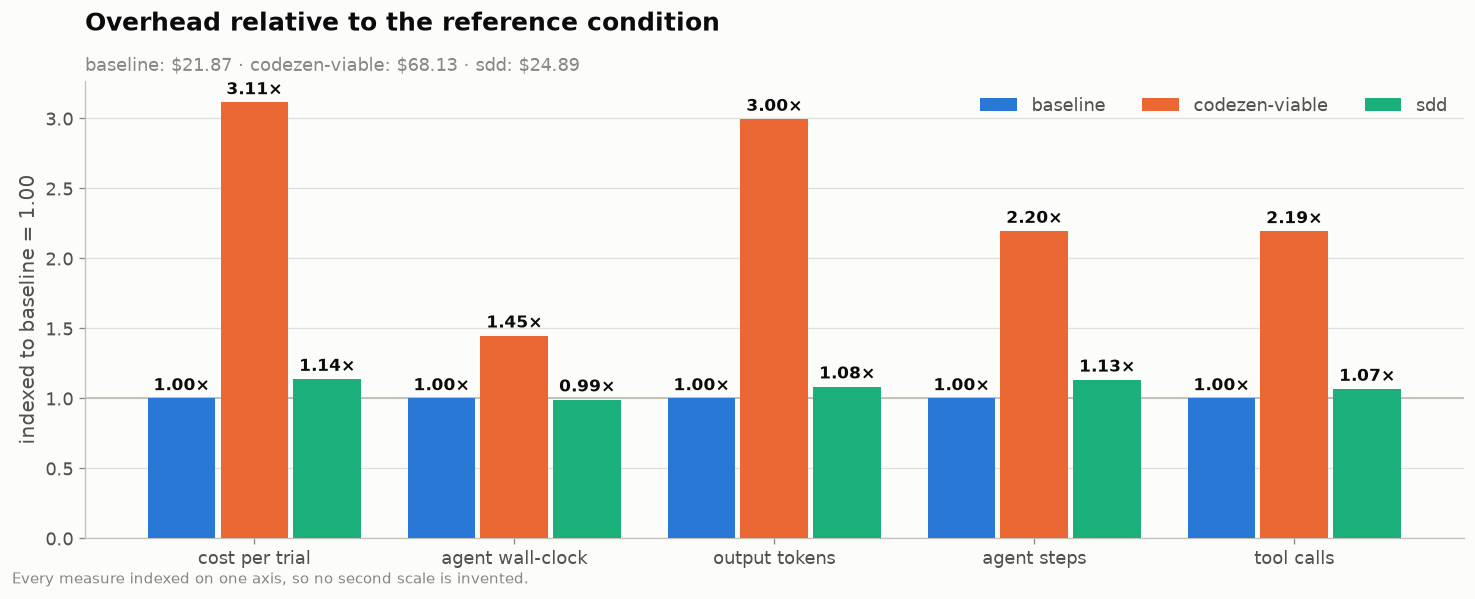

In [8]:
index_cols = ["cost_per_trial", "agent_sec", "output_tokens", "steps", "tool_calls"]
index = summary[index_cols].div(summary.loc[CONDITIONS[0], index_cols])
labels = ["cost per trial", "agent wall-clock", "output tokens", "agent steps", "tool calls"]

fig, ax = plt.subplots(figsize=(12.4, 5.0))
x = np.arange(len(index_cols))
width = min(0.26, 0.8 / len(CONDITIONS))
for k, cond in enumerate(CONDITIONS):
    values = [index.loc[cond, col] for col in index_cols]
    pos = x + (k - (len(CONDITIONS) - 1) / 2) * (width + 0.02)
    ax.bar(pos, values, width=width, color=COLOR[cond], zorder=3, label=cond)
    for xi, v in zip(pos, values):
        ax.text(xi, v + 0.03, f"{v:.2f}×", ha="center", va="bottom", fontsize=10, color=INK,
                fontweight="bold")
ax.axhline(1.0, color=AXIS, lw=1.2, zorder=2)
bare(ax)
ax.set_xticks(x, labels)
ax.set_ylabel(f"indexed to {CONDITIONS[0]} = 1.00")
titled(ax, "Overhead relative to the reference condition",
       " · ".join(f"{c}: ${summary.loc[c, 'cost_usd']:.2f}" for c in CONDITIONS))
ax.legend(loc="upper right", ncol=len(CONDITIONS))
fig.tight_layout()
save(fig, "03-overhead", "Every measure indexed on one axis, so no second scale is invented.")
plt.show()

figures/04-budget.png  figures/04-budget.svg


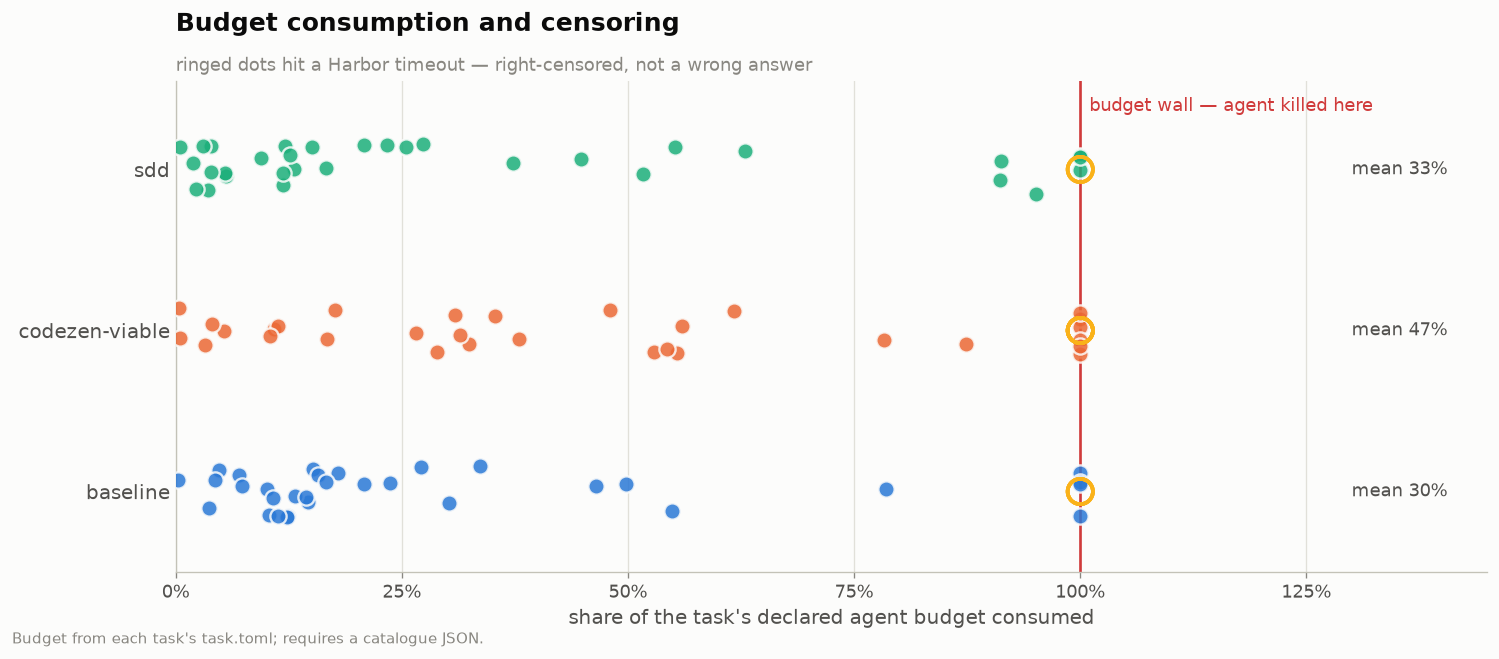

In [9]:
if not trials.budget_used.notna().any():
    print("skip  budget figure: budget_used is empty (no task catalogue; see cell 1)")
else:
    fig, ax = plt.subplots(figsize=(12.6, 1.3 * len(CONDITIONS) + 1.6))
    rng = np.random.default_rng(0)
    for k, cond in enumerate(CONDITIONS):
        sub = trials[trials.condition == cond]
        ax.scatter(sub.budget_used, np.full(len(sub), k) + rng.uniform(-0.16, 0.16, len(sub)),
                   s=95, color=COLOR[cond], alpha=0.85, zorder=3, edgecolors=SURFACE, linewidths=1.4)
        censored = sub[sub.agent_timeout | sub.verifier_timeout]
        ax.scatter(censored.budget_used, np.full(len(censored), k), s=230, facecolors="none",
                   edgecolors=WARNING, linewidths=2.2, zorder=4)
        ax.text(1.30, k, f"mean {sub.budget_used.mean():.0%}", va="center", fontsize=11, color=INK_2)
    ax.axvline(1.0, color=CRITICAL, lw=1.6, zorder=2)
    ax.text(1.01, len(CONDITIONS) - 0.55, "budget wall — agent killed here", fontsize=10.5,
            color=CRITICAL, va="top")
    bare(ax, grid_axis="x")
    ax.set_yticks(range(len(CONDITIONS)), CONDITIONS, fontsize=12)
    ax.tick_params(axis="y", length=0)
    ax.set_ylim(-0.5, len(CONDITIONS) - 0.45)
    ax.set_xlim(0, 1.45)
    ax.set_xticks(np.arange(0, 1.26, 0.25), [f"{v:.0%}" for v in np.arange(0, 1.26, 0.25)])
    ax.set_xlabel("share of the task's declared agent budget consumed")
    titled(ax, "Budget consumption and censoring",
           "ringed dots hit a Harbor timeout — right-censored, not a wrong answer")
    fig.tight_layout()
    save(fig, "04-budget", "Budget from each task's task.toml; requires a catalogue JSON.")
    plt.show()

    trials.groupby("condition", observed=True).agg(
        mean_budget_used=("budget_used", "mean"),
        over_75pct=("budget_used", lambda s: int((s > 0.75).sum())),
        agent_timeouts=("agent_timeout", "sum"),
        verifier_timeouts=("verifier_timeout", "sum"),
    ).round(3)

## 4. Behaviour and adherence

What changed in how the agent worked, and whether the methodology was actually invoked.
`skills_invoked` here is strict: a `Skill` tool call naming a skill the variant installed.
Claude Code loads a project `CLAUDE.md` silently, so a low "named the instruction file"
count is not evidence the file was absent — preflight is what proves presence.

figures/05-behaviour.png  figures/05-behaviour.svg


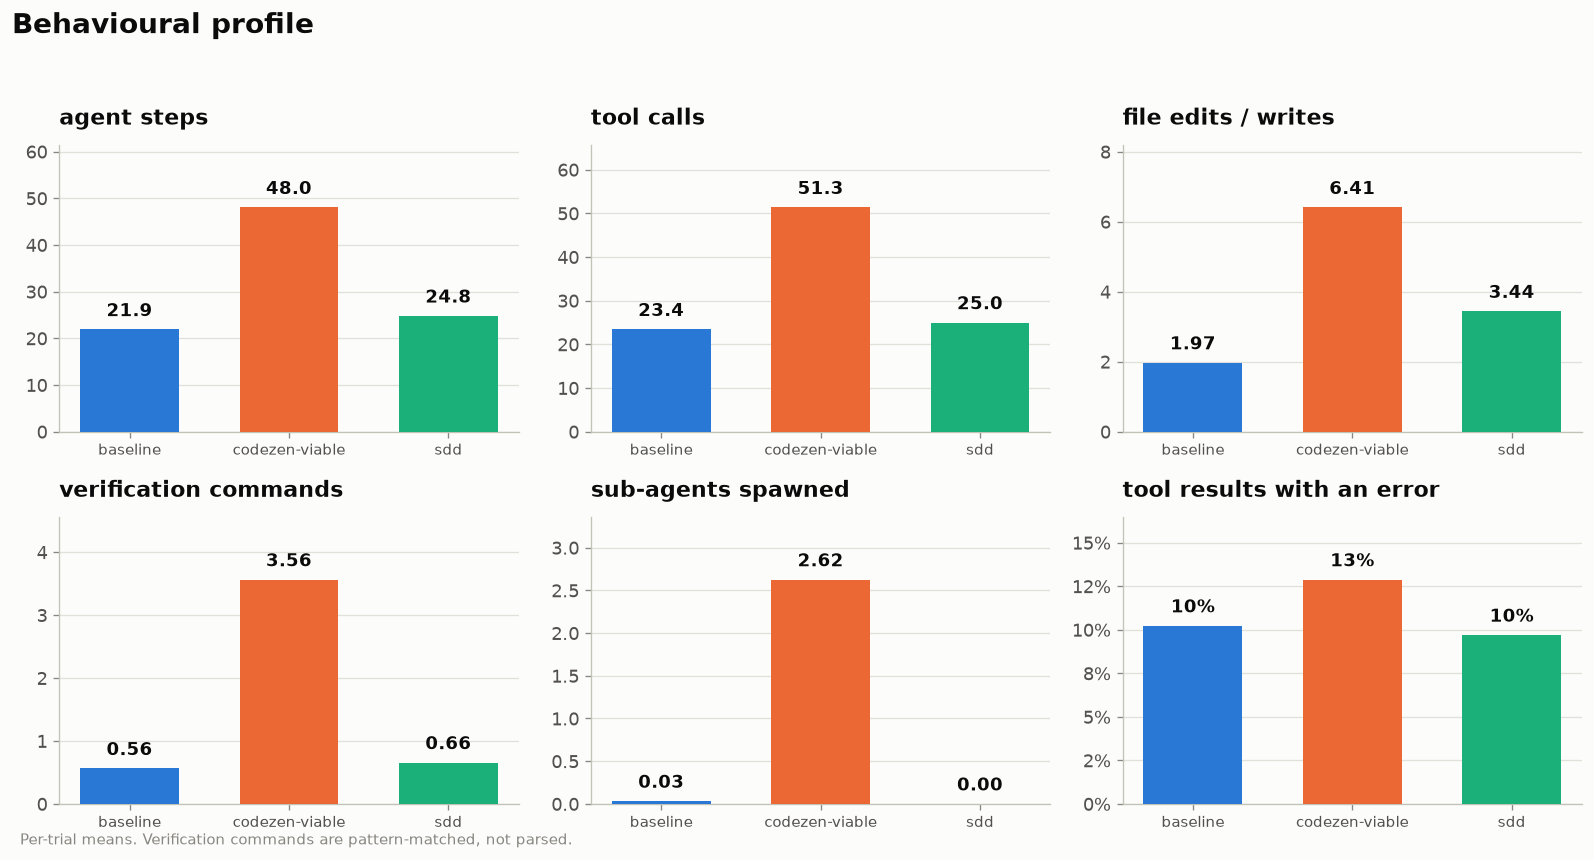

In [10]:
behaviour = [("n_steps", "agent steps"), ("n_tool_calls", "tool calls"),
             ("n_edits_total", "file edits / writes"),
             ("bash_test", "verification commands"), ("n_agent_spawns", "sub-agents spawned"),
             ("error_rate", "tool results with an error")]
fig, axes = plt.subplots(2, 3, figsize=(13.33, 6.8))
for ax, (col, label) in zip(axes.ravel(), behaviour):
    values = [trials.loc[trials.condition == c, col].mean() for c in CONDITIONS]
    peak = max([v for v in values if not pd.isna(v)] or [1])
    for i, cond in enumerate(CONDITIONS):
        ax.bar(i, values[i], width=0.62, color=COLOR[cond], zorder=3)
        text = f"{values[i]:.0%}" if col == "error_rate" else (
            f"{values[i]:.2f}" if peak < 10 else f"{values[i]:.1f}")
        ax.text(i, values[i] + peak * 0.04, text, ha="center", va="bottom", fontsize=11,
                color=INK, fontweight="bold")
    bare(ax)
    ax.set_xticks(range(len(CONDITIONS)), CONDITIONS, fontsize=9)
    ax.set_ylim(0, peak * 1.28)
    if col == "error_rate":
        ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(xmax=1, decimals=0))
    ax.set_title(label, loc="left", fontsize=13)
fig.suptitle("Behavioural profile", x=0.005, ha="left", fontsize=17, fontweight="bold",
             color=INK, y=1.03)
fig.tight_layout()
save(fig, "05-behaviour", "Per-trial means. Verification commands are pattern-matched, not parsed.")
plt.show()

figures/06-adherence.png  figures/06-adherence.svg


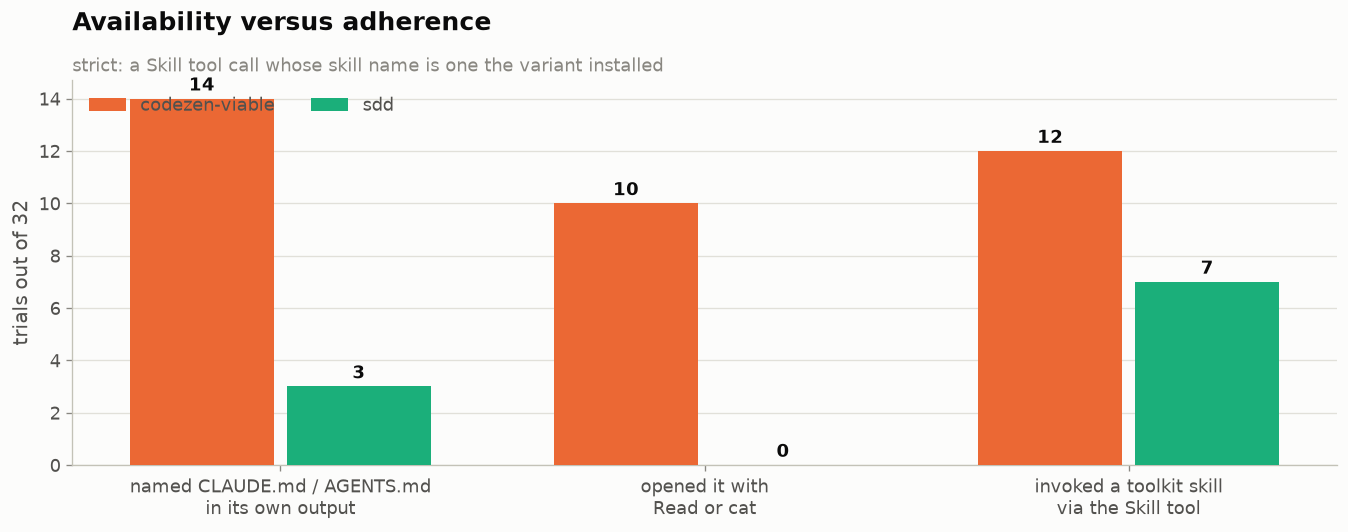

,baseline,codezen-viable,sdd
skills shipped,0,4,7
registered by the CLI,0,4,7
trials naming an instruction file,0,14,3
trials opening one,0,10,0
trials invoking a toolkit skill,0,12,7
toolkit Skill calls in total,0,28,27


In [11]:
toolkit_conditions = [c for c in CONDITIONS if c != "baseline"
                      and trials.loc[trials.condition == c, "n_toolkit_skills"].max() > 0]
adherence = pd.DataFrame({
    "skills shipped": [trials.loc[trials.condition == c, "n_toolkit_skills"].max() for c in CONDITIONS],
    "registered by the CLI": [trials.loc[trials.condition == c, "n_toolkit_skills_registered"].max() for c in CONDITIONS],
    "trials naming an instruction file": [int(trials.loc[trials.condition == c, "config_markers"]
                                          .fillna("").ne("").sum()) for c in CONDITIONS],
    "trials opening one": [int((trials.loc[trials.condition == c, "n_config_reads"] > 0).sum()) for c in CONDITIONS],
    "trials invoking a toolkit skill": [int((trials.loc[trials.condition == c, "n_toolkit_skill_calls"] > 0).sum()) for c in CONDITIONS],
    "toolkit Skill calls in total": [int(trials.loc[trials.condition == c, "n_toolkit_skill_calls"].sum()) for c in CONDITIONS],
}, index=CONDITIONS).T

if toolkit_conditions:
    stages = ["trials naming an instruction file", "trials opening one",
              "trials invoking a toolkit skill"]
    fig, ax = plt.subplots(figsize=(11.4, 4.6))
    x = np.arange(len(stages))
    width = min(0.34, 0.8 / len(toolkit_conditions))
    for k, cond in enumerate(toolkit_conditions):
        values = [adherence.loc[s, cond] for s in stages]
        pos = x + (k - (len(toolkit_conditions) - 1) / 2) * (width + 0.03)
        ax.bar(pos, values, width=width, color=COLOR[cond], zorder=3, label=cond)
        for xi, v in zip(pos, values):
            ax.text(xi, v + 0.14, f"{v:.0f}", ha="center", va="bottom", fontsize=11, color=INK,
                    fontweight="bold")
    bare(ax)
    ax.set_xticks(x, ["named CLAUDE.md / AGENTS.md\nin its own output",
                      "opened it with\nRead or cat", "invoked a toolkit skill\nvia the Skill tool"],
                  fontsize=10.5)
    ax.set_ylabel(f"trials out of {int(summary.trials.max())}")
    titled(ax, "Availability versus adherence",
           "strict: a Skill tool call whose skill name is one the variant installed")
    ax.legend(loc="upper left", ncol=len(toolkit_conditions))
    fig.tight_layout()
    save(fig, "06-adherence")
    plt.show()

adherence

In [12]:
used = trials[trials.n_toolkit_skill_calls > 0][
    ["task", "condition", "skill_call_sequence", "n_agent_spawns", "success", "cost_usd",
     "budget_used", "exception_type"]
].sort_values(["condition", "task"])
print(f"{len(used)} of {len(trials)} trials invoked a toolkit skill")
used.round(2)

19 of 96 trials invoked a toolkit skill


,task,condition,skill_call_sequence,n_agent_spawns,success,cost_usd,budget_used,exception_type
0,adaptive-rejection-sampler,codezen-viable,noc-tdd;code-review;noc-fix,6,True,2.87,1.00,AgentTimeoutError
5,adaptive-rejection-sampler,codezen-viable,noc-tdd;code-review,6,False,2.75,1.00,AgentTimeoutError
9,cancel-async-tasks,codezen-viable,noc-tdd,0,True,0.24,0.11,NaN
10,cancel-async-tasks,codezen-viable,noc-tdd;code-review,6,True,2.48,0.78,NaN
25,filter-js-from-html,codezen-viable,noc-tdd;code-review;security-review,9,False,6.74,1.00,AgentTimeoutError
29,filter-js-from-html,codezen-viable,noc-tdd;code-review;security-review,9,False,6.30,1.00,AgentTimeoutError
73,sam-cell-seg,codezen-viable,code-review;security-review,9,False,6.11,0.27,NaN
76,sam-cell-seg,codezen-viable,code-review;security-review,9,False,6.84,0.31,NaN
80,torch-tensor-parallelism,codezen-viable,noc-tdd;code-review;security-review,9,False,3.14,0.87,NaN
83,torch-tensor-parallelism,codezen-viable,noc-tdd;code-review,6,True,2.62,1.00,AgentTimeoutError


## 5. Exports and next steps

The tables under `data/` are the durable artefact — the figures can always be rebuilt from
them. Extend this notebook rather than starting a new one, so the run has a single
analysis of record.

Worth checking before drawing conclusions:

- **Discrimination.** If most tasks are concordant, the comparison had little power
  whatever the p-values say. Replace those tasks before spending on more attempts.
- **Censoring.** Report timeouts separately; folding them into a success rate converts
  "we stopped watching" into "it failed", and biases against conditions that add process.
- **Adherence.** A condition whose skills were never invoked measures "a repository
  containing a method", not "the method".
- **Attempts.** Variance claims need `--attempts` ≥ 3; with one attempt per cell there is
  no within-cell replicate.

In [13]:
out = DATA_DIR
summary.round(4).to_csv(out / "condition_summary.csv")
if len(paired):
    paired.round(4).to_csv(out / "paired_tests.csv", index=False)
outcome.astype(int).to_csv(out / "outcome_matrix.csv")
adherence.to_csv(out / "adherence.csv")
print("tables:", *sorted(p.name for p in out.glob("*.csv")), sep="\n  ")
print("figures:", *sorted(p.name for p in FIG_DIR.glob("*.png")), sep="\n  ")

tables:
  adherence.csv
  condition_summary.csv
  outcome_matrix.csv
  paired_tests.csv
  steps.csv
  tests.csv
  tool_calls.csv
  trials.csv
figures:
  01-outcome.png
  02-outcome-matrix.png
  03-overhead.png
  04-budget.png
  05-behaviour.png
  06-adherence.png
